In [3]:
%%capture
import os, mne
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

root_derivatives = 'C:/Users/mfbpe/Desktop/DATA/2025_Valuation/derivatives/'

# Change the current working directory to the derivatives directory
os.chdir(root_derivatives)

conditions = ['motiv/extr', 'motiv/hard', 'motiv/easy', 'amotiv/extr', 'amotiv/hard', 'amotiv/easy']



TFR_files={}
evokeds_TFR_all = {}
for cond in conditions:
    TFR_files[cond] = glob('*_'+cond.replace('/','-')+'_tfr.h5')

    evokeds_TFR_all[cond] = mne.grand_average([mne.time_frequency.read_tfrs(x) for x in TFR_files[cond]])

In [6]:
tfr_gr = mne.grand_average(
    [evokeds_TFR_all[cond] for cond in conditions]
)

Identifying common channels ...


No baseline correction applied


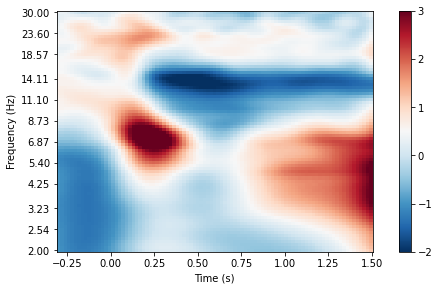

[<Figure size 432x288 with 2 Axes>]

In [207]:
%matplotlib inline
tfr_gr.plot(picks=['FCz','Fz'], combine='mean', vlim=(-2, 3))

No baseline correction applied
No baseline correction applied


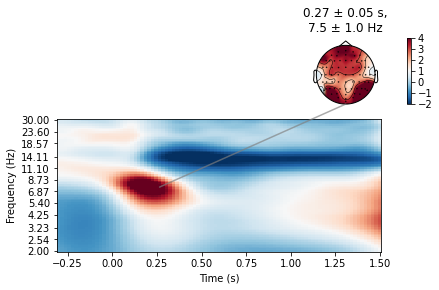

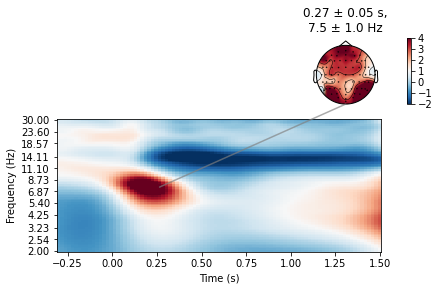

In [222]:
tfr_gr.plot_joint(
    timefreqs={(0.265, 7.5): (0.1, 2)},
    cmap="RdBu_r",
    vlim=(-2, 3),
    topomap_args=dict(vlim=(-2, 4), cmap="RdBu_r")
)

In [142]:
easy = evokeds_TFR_all['motiv/hard'].copy()
easy.data += evokeds_TFR_all['amotiv/hard'].data 
easy.data /= 2

hard = evokeds_TFR_all['motiv/extr'].copy()
hard.data += evokeds_TFR_all['amotiv/extr'].data 
hard.data /= 2

contrast_difficulty = hard.copy()
contrast_difficulty.data -= easy.data

No baseline correction applied


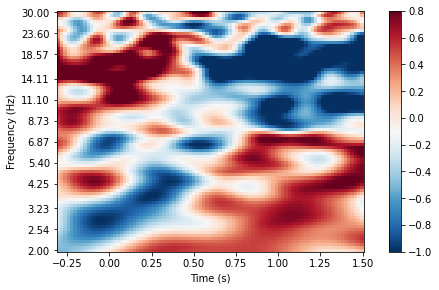

[<Figure size 432x288 with 2 Axes>]

In [208]:
contrast_difficulty.plot(picks=['FCz','Fz'], combine='mean', vlim=(-1, .8))

No baseline correction applied


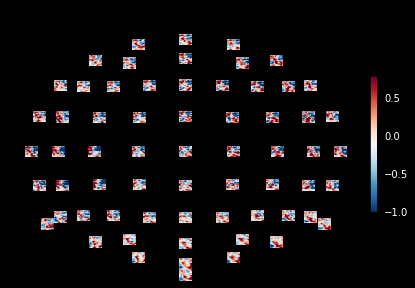

In [223]:
%matplotlib qt
contrast_difficulty.plot_topo(vmin=-1,vmax=.8)

No baseline correction applied
No baseline correction applied


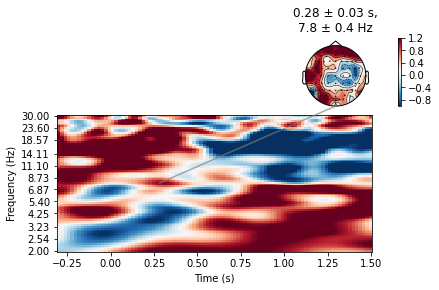

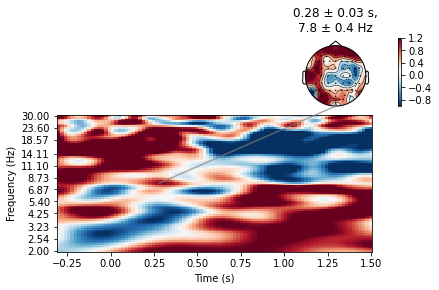

In [243]:
%matplotlib inline
contrast_difficulty.plot_joint(
    timefreqs={(.280, 7.8): (0.05, 0.8)},
    cmap="RdBu_r",
    picks=['FCz','Fz'], combine='mean',
    vlim=(-1, .5),
    topomap_args=dict(vlim=(-1, 1.2), cmap="RdBu_r")
)

In [225]:
motiv = evokeds_TFR_all['motiv/hard'].copy()
motiv.data += evokeds_TFR_all['motiv/easy'].data 
motiv.data += evokeds_TFR_all['motiv/extr'].data 
motiv.data /= 3

amotiv = evokeds_TFR_all['amotiv/hard'].copy()
amotiv.data += evokeds_TFR_all['amotiv/easy'].data 
amotiv.data += evokeds_TFR_all['amotiv/extr'].data 
amotiv.data /= 3

contrast_motiv = motiv.copy()
contrast_motiv.data -= amotiv.data

No baseline correction applied


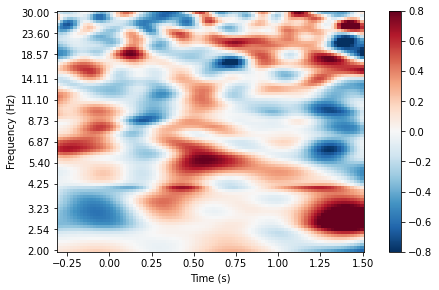

[<Figure size 432x288 with 2 Axes>]

In [226]:
contrast_motiv.plot(picks=['Pz','CPz'], combine='mean',vlim=(-.8, .8))

No baseline correction applied


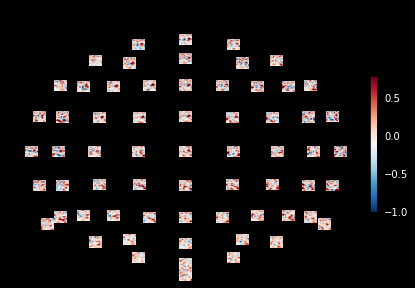

In [200]:
%matplotlib qt
contrast_motiv.plot_topo(vmin=-1,vmax=.8)

No baseline correction applied
No baseline correction applied


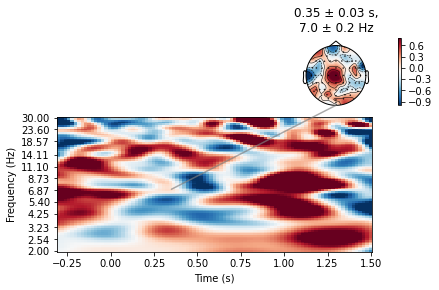

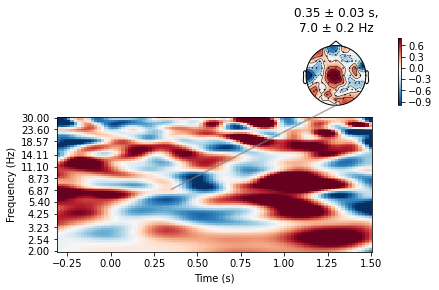

In [244]:
%matplotlib inline
contrast_motiv.plot_joint(
    timefreqs={(.350, 7): (0.05, 0.5)},
    cmap="RdBu_r",
    vlim=(-.3, .2),
    topomap_args=dict(vlim=(-1, .8), cmap="RdBu_r")
)

No baseline correction applied
No baseline correction applied


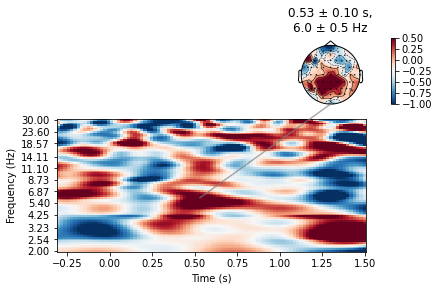

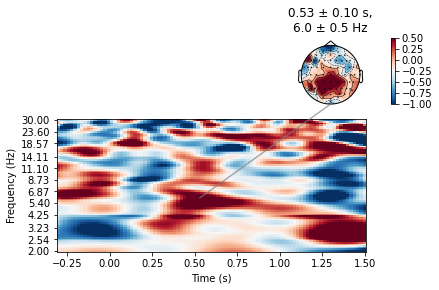

In [245]:
%matplotlib inline
contrast_motiv.plot_joint(
    timefreqs={(.530, 6): (0.2, 1)},
    cmap="RdBu_r",
    picks=['Pz','CPz'], combine='mean',
    vlim=(-.5, .5),
    topomap_args=dict(vlim=(-1, .5), cmap="RdBu_r")
)

In [249]:
tfr_gr

Data type,Average Power
Data source,Evoked
Number of averaged trials,6
Dims,"channel, freq, time"
Estimation method,morlet
Number of channels,64
Number of timepoints,93
Number of frequency bins,80
Frequency range,2.00 – 30.00 Hz


In [394]:
%%capture
tfr_gr_comb = tfr_gr.copy().pick(['FCz','Fz']).crop(tmin=-.25, tmax=1, fmin=2, fmax=30)

tfr_gr_comb.data = np.mean(tfr_gr_comb.data, axis=1)
# Statistical thresholds for significance (z-scores)
p01, p005, p001 = [1.65, 1.96, 2.58]

# Calculate upper and lower significance thresholds using the 95% confidence interval

signif_up = np.mean(tfr_gr_comb.data) + (p001 * np.std(tfr_gr_comb.data))
signif_down = np.mean(tfr_gr_comb.data) - (p001 * np.std(tfr_gr_comb.data))

tfr_gr_comb = tfr_gr.copy().pick(['FCz','Fz'])
tfr_gr_comb.data = np.mean(tfr_gr_comb.data, axis=0)

# Mark significant data points
tfr_gr_comb.data[tfr_gr_comb.data > signif_up] = 100

# Create a mask for plotting significant areas
mask_frontal = tfr_gr_comb.data ==False
mask_frontal[tfr_gr_comb.data==100]= True
mask_frontal[np.where(tfr_gr_comb.freqs<=12)[0][-1]:,:]= False
mask_frontal[:,np.where(tfr_gr_comb.times<=.5)[0][-1]:]= False
# mask_frontal[:,:np.where(tfr_gr_comb.times>=0)[0][0]]= False

No baseline correction applied


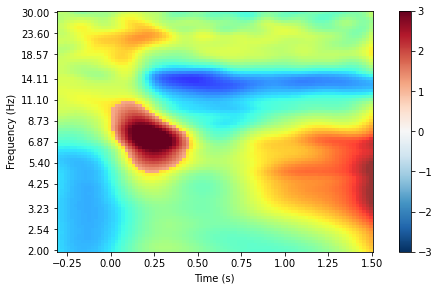

[<Figure size 432x288 with 2 Axes>]

In [395]:
tfr_gr.plot(vlim=(-3,3), mask=np.squeeze(mask_frontal), cmap="RdBu_r" ,picks=['FCz','Fz'], combine='mean',mask_cmap='jet',mask_alpha=.8, mask_style="contour")


In [396]:
%%capture
tfr_gr_comb = tfr_gr.copy().pick(['CPz','Pz']).crop(tmin=-0.25, tmax=1, fmin=2, fmax=30)

tfr_gr_comb.data = np.mean(tfr_gr_comb.data, axis=1)
# Statistical thresholds for significance (z-scores)
p01, p005, p001 = [1.65, 1.96, 2.58]

# Calculate upper and lower significance thresholds using the 95% confidence interval

signif_up = np.mean(tfr_gr_comb.data) + (p005 * np.std(tfr_gr_comb.data))
signif_down = np.mean(tfr_gr_comb.data) - (p005 * np.std(tfr_gr_comb.data))

tfr_gr_comb = tfr_gr.copy().pick(['CPz','Pz'])
tfr_gr_comb.data = np.mean(tfr_gr_comb.data, axis=0)

# Mark significant data points
tfr_gr_comb.data[tfr_gr_comb.data < signif_down] = 100
tfr_gr_comb.data[tfr_gr_comb.data > signif_up] = 100

# Create a mask for plotting significant areas
mask_parietal = tfr_gr_comb.data ==False
mask_parietal[tfr_gr_comb.data==100]= True
mask_parietal[np.where(tfr_gr_comb.freqs<=10)[0][-1]:,:]= False
mask_parietal[:,np.where(tfr_gr_comb.times<=1)[0][-1]:]= False
mask_parietal[:,:np.where(tfr_gr_comb.times>=.4)[0][0]]= False

No baseline correction applied


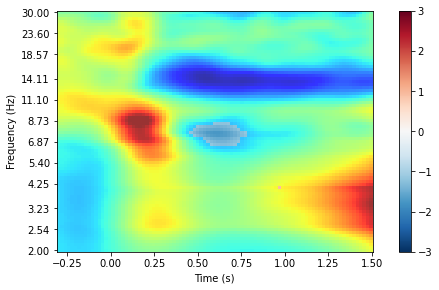

[<Figure size 432x288 with 2 Axes>]

In [397]:
tfr_gr.plot(vlim=(-3,3), mask=np.squeeze(mask_parietal), cmap="RdBu_r" ,picks=['CPz','Pz'], combine='mean',mask_cmap='jet',mask_alpha=.8, mask_style="contour")


In [398]:
np.save("mask_parietal.npy",mask_parietal)
np.save("mask_frontal.npy",mask_frontal)


